## Question 10:
 Application of SVD for image noise reduction.
 
 Using the provided noisy grayscale image (Link), apply Singular Value Decomposition <br/>
 (SVD) to perform image noise reduction by reconstructing the image using a lower-rank approximation.<br/> 
 Plot and analyze how image quality changes as you vary the number of singular
 values retained.

In [ ]:
# Load required libraries
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Load the image for analysis. 
# For this assignment have stored and placed the image file 'grayscale_cat_noise.png' in same folder where this '.ipynb' file is located
X = imread(os.path.join('grayscale_cat_noise.png'))
# Loaded image is 3D with color channel also. Needs to be reshaped to a 2D. Following code converts the loaded image to 2D
X = np.mean(X, -1) 
# If not converted, leads to error as Sigma value generated turns into size of the color channel instead of k. 
# Leading to multiple erros while reconstructing image based on different ranks
X

array([[0.26764706, 0.2617647 , 0.2647059 , ..., 0.40882355, 0.517647  ,
        0.55      ],
       [0.30294117, 0.2617647 , 0.2647059 , ..., 0.4       , 0.47352943,
        0.55      ],
       [0.25      , 0.25      , 0.2617647 , ..., 0.4       , 0.4911765 ,
        0.5088235 ],
       ...,
       [0.35588235, 0.3529412 , 0.28529412, ..., 0.46470588, 0.47352943,
        0.45294118],
       [0.35000002, 0.3529412 , 0.3529412 , ..., 0.46764708, 0.4382353 ,
        0.5441177 ],
       [0.36176473, 0.35882354, 0.3529412 , ..., 0.46764708, 0.5441177 ,
        0.47058824]], shape=(400, 600), dtype=float32)

In [72]:
print("Image shape: ", X.shape)
storage_X = X.size
print(f"File size: {storage_X}") 

Image shape:  (400, 600)
File size: 240000


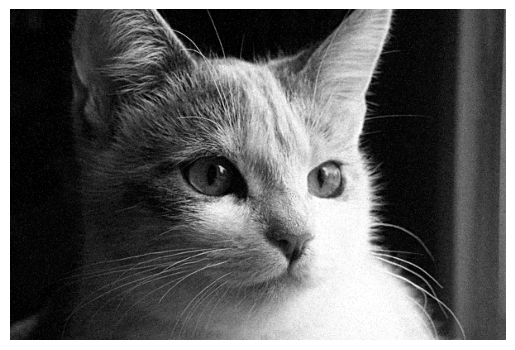

In [67]:
# Visualize the original Image
img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.show()

In [121]:
# Perform SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)
S

array([2.5683929e+02, 4.0675972e+01, 3.0585579e+01, 2.2374243e+01,
       1.7946438e+01, 1.3139848e+01, 1.0063069e+01, 8.3863049e+00,
       7.5025220e+00, 6.9107270e+00, 6.5908427e+00, 6.2909260e+00,
       5.8449569e+00, 5.1110229e+00, 4.8395610e+00, 4.4155517e+00,
       4.3353477e+00, 4.1560774e+00, 4.0726695e+00, 4.0195332e+00,
       3.9107292e+00, 3.7580614e+00, 3.6588335e+00, 3.5843160e+00,
       3.4628248e+00, 3.3977859e+00, 3.3682923e+00, 3.2919741e+00,
       3.2384095e+00, 3.2045960e+00, 3.1573565e+00, 3.0704770e+00,
       3.0193245e+00, 2.9406152e+00, 2.9004910e+00, 2.7528534e+00,
       2.7155936e+00, 2.6396885e+00, 2.6181233e+00, 2.5569677e+00,
       2.5548847e+00, 2.5194025e+00, 2.4657037e+00, 2.4547400e+00,
       2.4132099e+00, 2.3833244e+00, 2.3625560e+00, 2.3429737e+00,
       2.3110478e+00, 2.2705383e+00, 2.2484531e+00, 2.1980522e+00,
       2.1546452e+00, 2.1490149e+00, 2.1112986e+00, 2.1074986e+00,
       2.0467176e+00, 2.0345361e+00, 2.0323949e+00, 1.9995832e

In [88]:
# This was to handle the shape problem as initially read the image as tensor
Sigma = np.zeros(X.shape)
Sigma[:,:][:S.shape[0], :S.shape[0]] = np.diag(S)
# This block not required as fixed the code to read image as a 2D array instead of 3D with color channel

## Plot Singular values vs rank

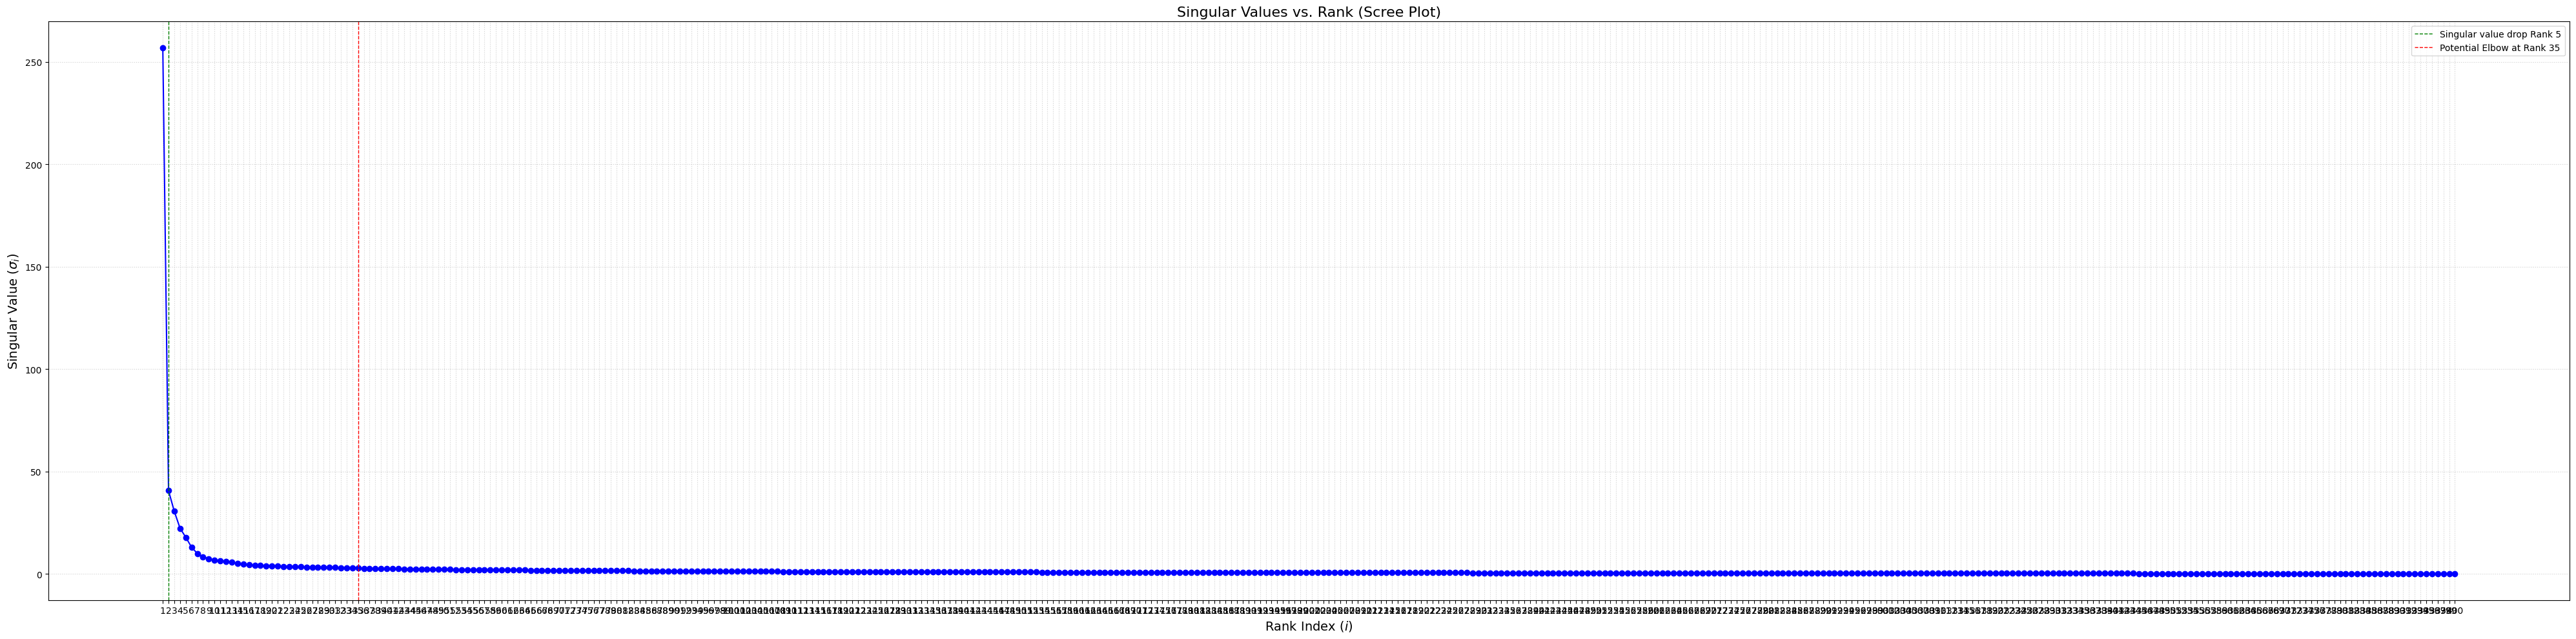

In [123]:
# Plot Singular values vs rank

# Setting up the index for X-axis with indexes from generated Sigma
rank_index = np.arange(1, len(S) +1)

# Setting up the plot
plt.figure(figsize=(40,10))

plt.plot(rank_index, S, marker='o', linestyle='-', color='blue')

plt.title('Singular Values vs. Rank (Scree Plot)', fontsize=16)
plt.xlabel('Rank Index ($i$)', fontsize=14)
plt.ylabel('Singular Value ($\sigma_i$)', fontsize=14)

# Setting up a vertical line on graph to represent position where singular values have a drop
plt.axvline(x=2, color='green', linestyle='--', linewidth=1, label=f'Singular value drop Rank {5}')
# Setting up a vertical line on graph to represent position where rank increment stabilizes from singular value perspective
elbow_rank = 35
plt.axvline(x=elbow_rank, color='red', linestyle='--', linewidth=1, label=f'Potential Elbow at Rank {elbow_rank}')
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rank_index) # Ensure all rank indices are visible on the x-axis
plt.tight_layout()

plt.show()


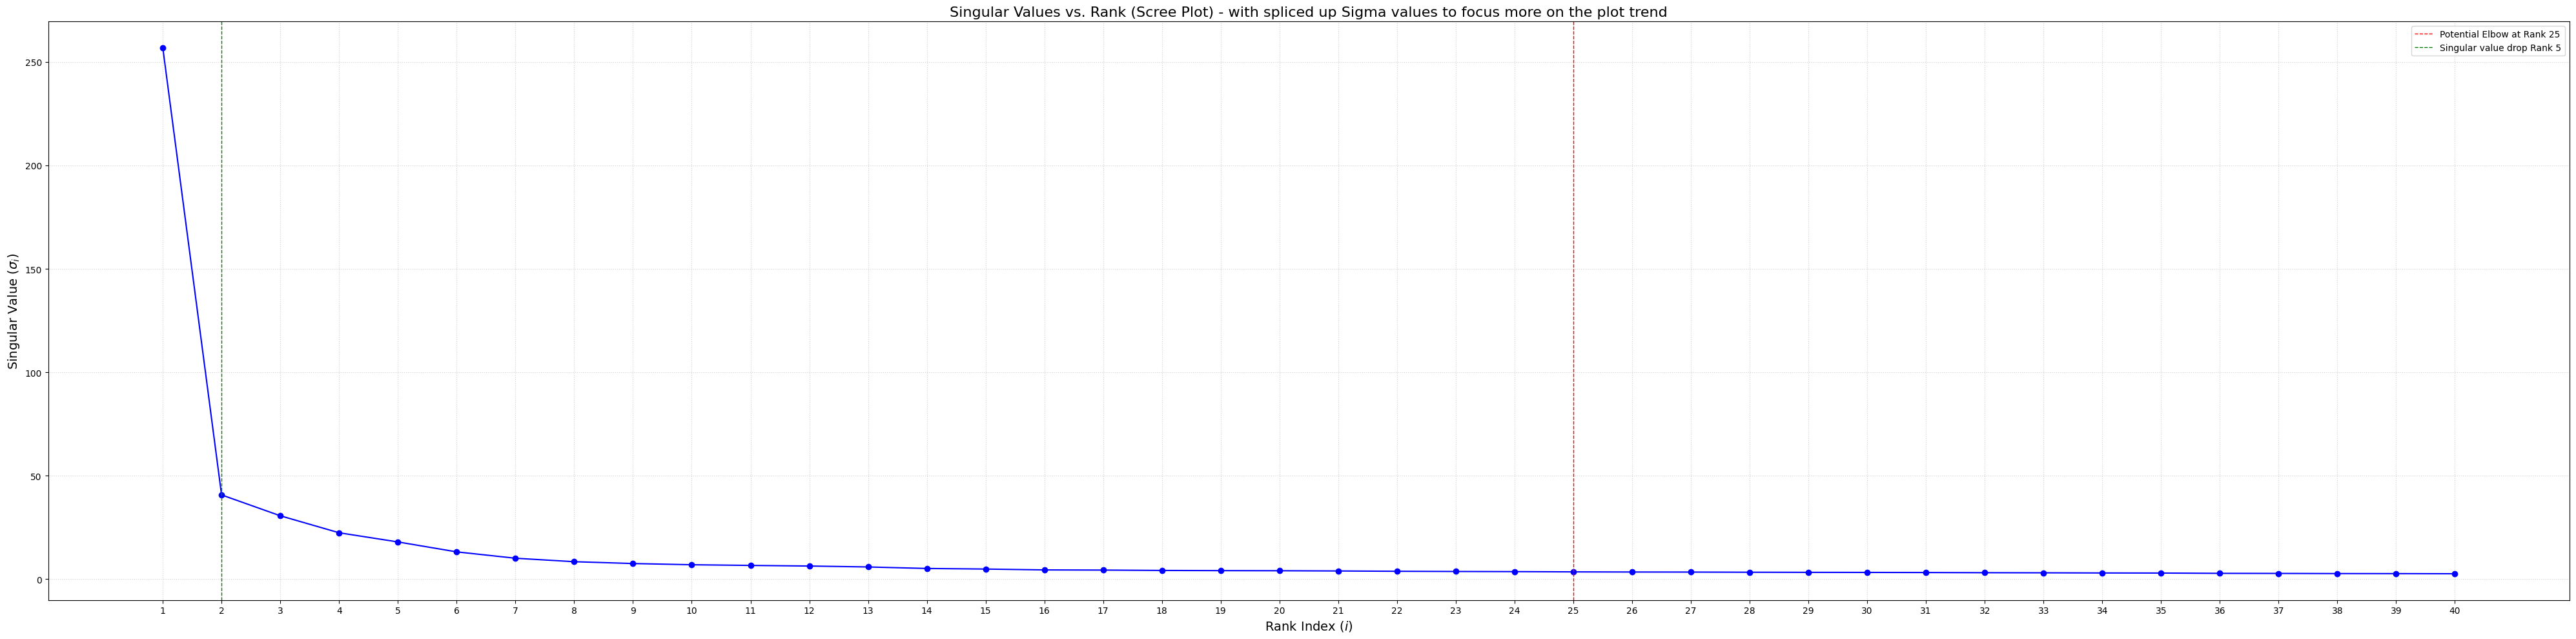

In [ ]:
# Plot Singular values vs rank

# Another plot to have a focussed look at Sigma for index 0 - 40, based on previous overall evaluation where not much change in Singular values was observed post rank 40
rank_index = np.arange(1, len(S[:40]) +1)

plt.figure(figsize=(40,10))

plt.plot(rank_index, S[:40], marker='o', linestyle='-', color='blue')

plt.title('Singular Values vs. Rank (Scree Plot) - with spliced up Sigma values to focus more on the plot trend', fontsize=16)
plt.xlabel('Rank Index ($i$)', fontsize=14)
plt.ylabel('Singular Value ($\sigma_i$)', fontsize=14)

elbow_rank = 25
plt.axvline(x=elbow_rank, color='red', linestyle='--', linewidth=1, label=f'Potential Elbow at Rank {elbow_rank}')
plt.axvline(x=2, color='green', linestyle='--', linewidth=1, label=f'Singular value drop Rank {5}')
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rank_index) # Ensure all rank indices are visible on the x-axis
plt.tight_layout()

plt.show()


## Decide an appropriate rank cutoff for reconstruction and justify your choice based on the
## singular value distribution and image quality.
Answer: 
Looking at the Singular values vs rank plot - Singular value drops sharply at rank=2 and continues to drop between 2 to 20-25. Post 25 the graph is almost a line parallel to X-axis.

With this observation I would like to consider 25 as cut-off point.

### Based on observation - cut-off point: 25 

In [ ]:
# Create a Diagonal matrix (2-D) from generated Sigma which is currently 1-D
S = np.diag(S)
print(f"U Shape: {U.shape}, S Shape: {S.shape}, VT Shape: {VT.shape}")
S

U Shape: (400, 400), S Shape: (400, 400), VT Shape: (400, 600)


array([[2.5683929e+02, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 4.0675972e+01, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 3.0585579e+01, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.5767175e-01,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.4838767e-01, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 1.4425763e-01]], shape=(400, 400), dtype=float32)

## Reconstruct and display the image for different ranks (e.g., r = 5, 10,... and your chosen cutoff rank)

In [118]:
# Rank-r approximation
rank_approximation = [5, 10, 25, 35, 50, 100]

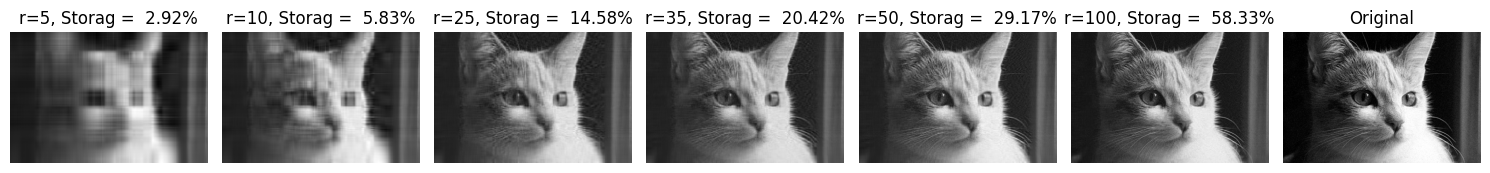

In [119]:
# Reconstruct and display the image for different ranks (e.g., r = 5, 10,... and your chosen
# cutoff rank).
# Subplots
fig, axes = plt.subplots(1, len(rank_approximation)+1, figsize=(15, 5))

for i,r in enumerate(rank_approximation):
    # For every rank-approximation for a rank 'r' :
    # If A = U S VT , where A is a matrix of size m X n, then
    # U is matrix of size m X r
    # S is matrix of dize r X r
    # VT is matrix of size r X n
    X_approx = U[:,:r] @ S[:r, :r] @ VT[:r, :]
    storage_X_approx = U[:, :r].size + S[:r].size + VT[:r, :].size
    storage_percent = round((storage_X_approx / storage_X) * 100, 2)

    ax = axes[i]
    img = ax.imshow(X_approx, cmap='gray')
    ax.axis('off')
    ax.set_title(f"r={r}, Storag = {storage_percent: .2f}%")

ax = axes[len(rank_approximation)]
img = ax.imshow(x, cmap='gray')
ax.axis('off')
ax.set_title('Original')

plt.tight_layout()
plt.show()